# Eksperimen SML - Heart Disease Prediction
**Nama:** Trinata Suryawan

Notebook ini merupakan tahap eksperimen (Kriteria 1) untuk proyek akhir
kelas *Membangun Sistem Machine Learning*. Alur mengikuti Template Eksperimen MSML:

1. **Data Loading** — memuat dataset mentah.
2. **Exploratory Data Analysis (EDA)** — memahami struktur, distribusi, korelasi.
3. **Data Preprocessing** — membersihkan, encoding, scaling, dan split data.

Dataset: **Heart Disease** (klasifikasi biner — memprediksi keberadaan penyakit
jantung berdasarkan 11 fitur klinis).

## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 42

## 2. Data Loading
Memuat dataset mentah `heart_raw.csv`. Dataset ini berisi data klinis pasien
dengan target `HeartDisease` (0 = tidak, 1 = ya).

In [2]:
df = pd.read_csv("heart_raw.csv")
print("Shape:", df.shape)
df.head()

Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,56,M,ATA,127,178,0,Normal,158,N,-0.1,Up,0
1,44,M,ASY,113,0,0,Normal,128,Y,1.8,Up,1
2,61,M,ASY,132,138,0,Normal,153,N,-1.9,Up,0
3,62,F,TA,167,298,0,ST,163,Y,1.4,Up,0
4,35,F,TA,103,0,1,Normal,155,N,2.0,Up,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


### Deskripsi Fitur
| Fitur | Keterangan |
|---|---|
| Age | Umur pasien (tahun) |
| Sex | Jenis kelamin (M/F) |
| ChestPainType | Tipe nyeri dada (ASY, NAP, ATA, TA) |
| RestingBP | Tekanan darah istirahat (mm Hg) |
| Cholesterol | Kolesterol serum (mg/dl) |
| FastingBS | Gula darah puasa > 120 mg/dl (1/0) |
| RestingECG | Hasil EKG istirahat (Normal, ST, LVH) |
| MaxHR | Detak jantung maksimum |
| ExerciseAngina | Angina akibat olahraga (Y/N) |
| Oldpeak | Depresi ST akibat olahraga |
| ST_Slope | Kemiringan segmen ST (Up, Flat, Down) |
| **HeartDisease** | **Target** — 1: sakit, 0: sehat |

## 3. Exploratory Data Analysis (EDA)

### 3.1 Statistik Deskriptif

In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.135076,132.848584,174.226580,0.241830,148.708061,0.830283,0.546841
std,9.236930,17.323843,92.072271,0.428425,23.525613,1.090885,0.498072
min,28.000000,90.000000,0.000000,0.000000,83.000000,-2.600000,0.000000
25%,47.000000,120.000000,140.000000,0.000000,134.000000,0.100000,0.000000
50%,53.000000,133.000000,194.000000,0.000000,148.000000,0.800000,1.000000
75%,59.000000,144.000000,235.000000,0.000000,165.000000,1.575000,1.000000
max,77.000000,192.000000,402.000000,1.000000,202.000000,4.300000,1.000000


In [5]:
df.describe(include="object")

/tmp/ipykernel_680/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,709,510,559,544,435


### 3.2 Pemeriksaan Missing Value & Nilai Anomali

In [6]:
print("Missing value per kolom:")
print(df.isnull().sum())

# Pada dataset ini, Cholesterol == 0 dan RestingBP == 0 secara medis tidak mungkin,
# sehingga diperlakukan sebagai missing value terselubung.
print("\nJumlah Cholesterol == 0 :", (df["Cholesterol"] == 0).sum())
print("Jumlah RestingBP == 0   :", (df["RestingBP"] == 0).sum())

Missing value per kolom:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Jumlah Cholesterol == 0 : 152
Jumlah RestingBP == 0   : 0


### 3.3 Distribusi Target

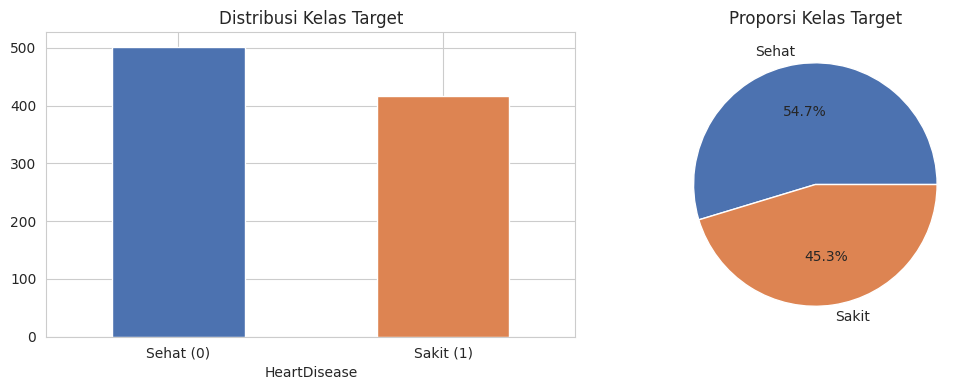

HeartDisease
1    0.547
0    0.453
Name: proportion, dtype: float64


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["HeartDisease"].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#DD8452"])
ax[0].set_title("Distribusi Kelas Target")
ax[0].set_xticklabels(["Sehat (0)", "Sakit (1)"], rotation=0)
df["HeartDisease"].value_counts().plot(kind="pie", ax=ax[1], autopct="%1.1f%%",
                                        labels=["Sehat", "Sakit"], colors=["#4C72B0", "#DD8452"])
ax[1].set_ylabel("")
ax[1].set_title("Proporsi Kelas Target")
plt.tight_layout()
plt.show()

print(df["HeartDisease"].value_counts(normalize=True).round(3))

### 3.4 Distribusi Fitur Numerik

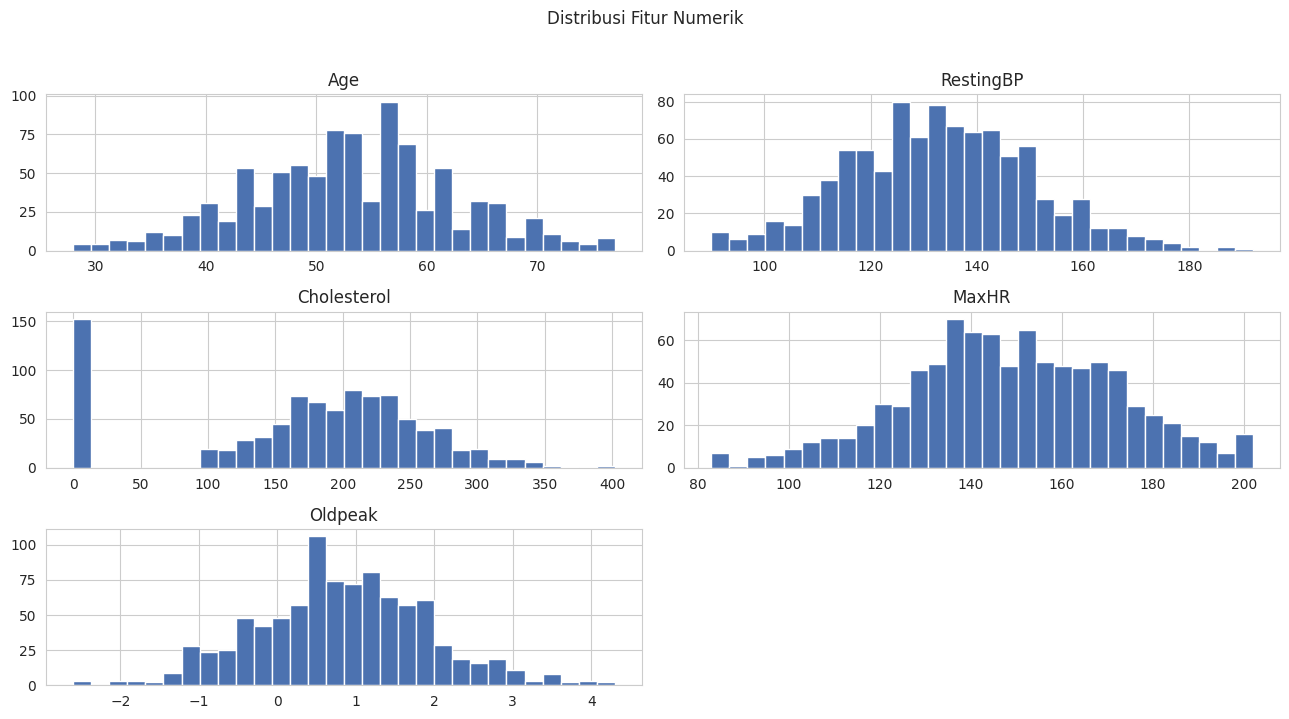

In [8]:
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
df[num_cols].hist(bins=30, figsize=(13, 7), color="#4C72B0", edgecolor="white")
plt.suptitle("Distribusi Fitur Numerik", y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Distribusi Fitur Kategorikal terhadap Target

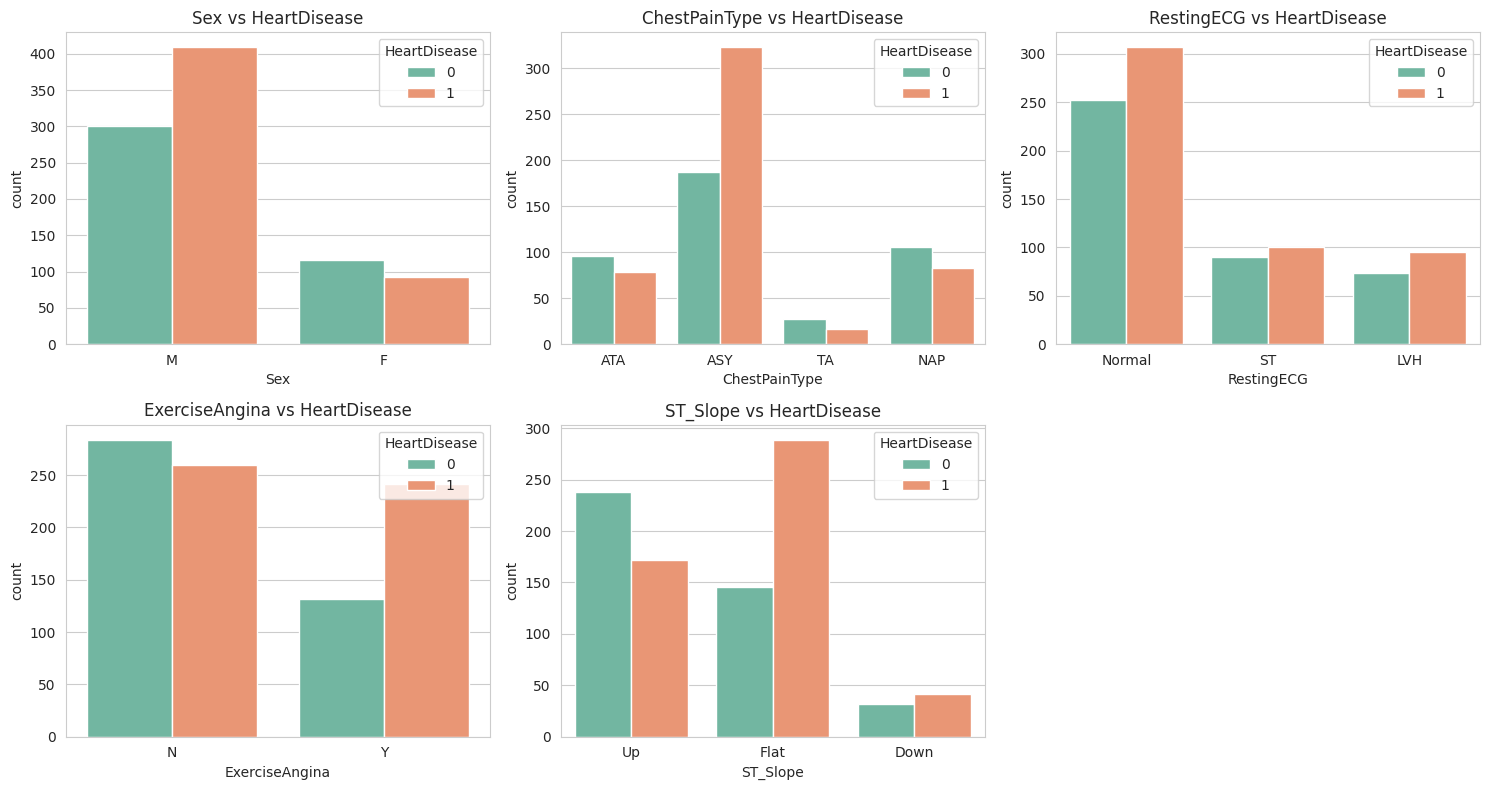

In [9]:
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue="HeartDisease", ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} vs HeartDisease")
for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

### 3.6 Korelasi Antar Fitur Numerik

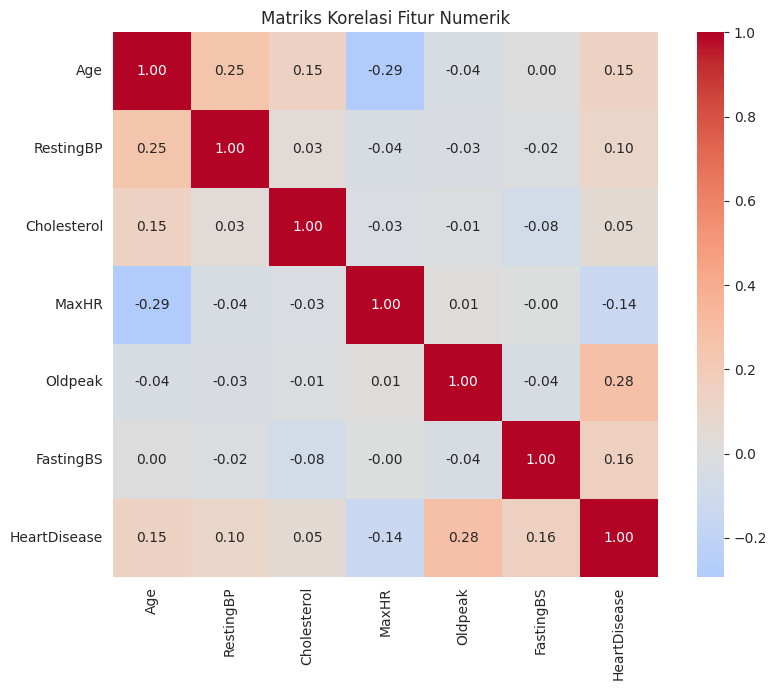

In [10]:
plt.figure(figsize=(9, 7))
corr = df[num_cols + ["FastingBS", "HeartDisease"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriks Korelasi Fitur Numerik")
plt.tight_layout()
plt.show()

### 3.7 Insight EDA
Beberapa temuan penting dari eksplorasi di atas:
- **Target relatif seimbang** (~55% sakit, ~45% sehat), sehingga *accuracy* masih layak dipakai walau tetap dilengkapi metrik lain.
- **Cholesterol** memiliki sejumlah nilai 0 yang tidak wajar secara medis → perlu ditangani sebagai *missing value*.
- **ChestPainType = ASY (asymptomatic)**, **ExerciseAngina = Y**, dan **ST_Slope = Flat/Down** tampak berasosiasi kuat dengan keberadaan penyakit jantung.
- **MaxHR** cenderung lebih rendah pada pasien sakit, sedangkan **Oldpeak** cenderung lebih tinggi.
- Fitur numerik memiliki skala yang berbeda-beda → perlu *scaling* sebelum masuk model berbasis jarak/gradien.

## 4. Data Preprocessing
Tahapan preprocessing dilakukan **secara manual** pada notebook ini. Langkah-langkahnya
akan dikonversi menjadi fungsi otomatis pada file `automate_Trinata-Suryawan.py` (Kriteria 1 - Skilled).

### 4.1 Menangani Missing Value Terselubung

In [11]:
df_clean = df.copy()

# Ganti Cholesterol == 0 dengan NaN lalu imputasi dengan median
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)
median_chol = df_clean["Cholesterol"].median()
df_clean["Cholesterol"] = df_clean["Cholesterol"].fillna(median_chol)
print(f"Cholesterol == 0 diganti median = {median_chol:.1f}")

# Jaga-jaga bila ada RestingBP == 0
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["RestingBP"] = df_clean["RestingBP"].fillna(df_clean["RestingBP"].median())

print("Sisa missing value:", df_clean.isnull().sum().sum())

Cholesterol == 0 diganti median = 208.0
Sisa missing value: 0


### 4.2 Menghapus Duplikat

In [12]:
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Baris dihapus (duplikat): {before - df_clean.shape[0]}")
print("Shape setelah dedup:", df_clean.shape)

Baris dihapus (duplikat): 0
Shape setelah dedup: (918, 12)


### 4.3 Encoding Fitur Kategorikal

In [13]:
# Binary mapping untuk fitur biner
df_clean["Sex"] = df_clean["Sex"].map({"M": 1, "F": 0})
df_clean["ExerciseAngina"] = df_clean["ExerciseAngina"].map({"Y": 1, "N": 0})

# One-hot encoding untuk fitur multi-kategori
multi_cat = ["ChestPainType", "RestingECG", "ST_Slope"]
df_clean = pd.get_dummies(df_clean, columns=multi_cat, drop_first=True)

# Ubah kolom hasil one-hot (bool) menjadi int
bool_cols = df_clean.select_dtypes(include="bool").columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print("Shape setelah encoding:", df_clean.shape)
df_clean.head()

Shape setelah encoding: (918, 16)


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,56,1,127,178.0,0,158,0,-0.1,0,1,0,0,1,0,0,1
1,44,1,113,208.0,0,128,1,1.8,1,0,0,0,1,0,0,1
2,61,1,132,138.0,0,153,0,-1.9,0,0,0,0,1,0,0,1
3,62,0,167,298.0,0,163,1,1.4,0,0,0,1,0,1,0,1
4,35,0,103,208.0,1,155,0,2.0,1,0,0,1,1,0,0,1


### 4.4 Memisahkan Fitur dan Target, lalu Train-Test Split

In [14]:
X = df_clean.drop(columns=["HeartDisease"])
y = df_clean["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (734, 15) | Test: (184, 15)


### 4.5 Standardisasi Fitur Numerik

In [15]:
num_features = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
scaler = StandardScaler()

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

X_train.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
602,1.294091,1,0.290366,0.258233,1,-0.030532,0,-1.600437,1,0,0,1,0,1,0
552,0.314178,1,-2.062425,-0.023436,1,-0.935582,0,0.257416,0,0,0,1,0,0,1
605,0.640815,0,0.118210,-0.546536,1,0.443541,0,1.279236,0,0,0,0,1,0,1
643,0.205298,0,0.290366,-0.727609,0,-1.409655,0,-1.135973,0,0,0,1,0,0,1
890,-0.774615,1,0.634677,-1.793929,0,0.960712,1,-1.693329,0,0,0,1,0,0,1


### 4.6 Menyimpan Hasil Preprocessing

In [16]:
import os
os.makedirs("preprocessing/namadataset_preprocessing", exist_ok=True)

# Gabungkan kembali untuk disimpan
train_out = X_train.copy(); train_out["HeartDisease"] = y_train.values
test_out = X_test.copy();  test_out["HeartDisease"] = y_test.values

train_out.to_csv("preprocessing/namadataset_preprocessing/train.csv", index=False)
test_out.to_csv("preprocessing/namadataset_preprocessing/test.csv", index=False)

print("Disimpan:")
print(" - preprocessing/namadataset_preprocessing/train.csv", train_out.shape)
print(" - preprocessing/namadataset_preprocessing/test.csv ", test_out.shape)

Disimpan:
 - preprocessing/namadataset_preprocessing/train.csv (734, 16)
 - preprocessing/namadataset_preprocessing/test.csv  (184, 16)


## 5. Kesimpulan
Melalui notebook ini telah dilakukan seluruh tahapan eksperimen secara manual:
data loading, EDA menyeluruh, dan preprocessing (penanganan *missing value*,
dedup, encoding, split, scaling).

Seluruh langkah preprocessing pada bagian 4 selanjutnya dikonversi menjadi
fungsi otomatis pada `automate_Trinata-Suryawan.py` sehingga dapat dijalankan
ulang secara konsisten, dan dijadwalkan otomatis melalui GitHub Actions.